# Subset Selection with Deployment Data

Cleaned subset-selection workflow with deterministic physical-fan validation. Feature and model selection use at most ten fan-balanced folds for practical runtime, while the final combined evaluation uses every per-fault fan combination. Approximately 30% of each fault's fans are assigned to testing, capped at four test fans when more than ten fans are available. All samples from a selected fan remain together, and preprocessing is fitted only on training data.

## 1. Setup and imports

Configure thread limits, import dependencies, and set warning/display behavior.

In [2]:
import os

# Limit native-library thread usage for reproducible, resource-conscious runs.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["POLARS_MAX_THREADS"] = "1"

import copy
import gc
import json
import warnings
import zlib
from itertools import combinations
from math import lcm
from statistics import mode

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from tqdm import tqdm

np.set_printoptions(suppress=True)

with warnings.catch_warnings():
    warnings.filterwarnings(action="ignore", category=ConvergenceWarning)

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

## 2. Load, validate, and merge feature data

Load the feature tables, normalize sample keys, validate uniqueness, merge one-to-one, and build metadata columns.

In [3]:
df_analog = pd.read_csv('corrected_feature_csvs/ctvt_singlefault_peaks_freq.csv')
df_digital = pd.read_csv('corrected_feature_csvs/digital_feats_updt.csv')
df_rpm_decays = pd.read_csv('corrected_feature_csvs/RPM_decays_over_quads.csv')
df_turns_before_stable = pd.read_csv('corrected_feature_csvs/turns_before_stable.csv')
df_stats = pd.read_csv('corrected_feature_csvs/stats_features_2.csv')
df_rpm_decays = df_rpm_decays.rename(columns={'id': 'sample_id_key'})
df_turns_before_stable = df_turns_before_stable.rename(columns={'id': 'sample_id_key'})
feature_files = {'analog': df_analog, 'digital': df_digital, 'rpm_decays': df_rpm_decays, 'turns_before_stable': df_turns_before_stable, 'stats': df_stats}
for name, df in feature_files.items():
    if 'sample_id_key' not in df.columns:
        raise ValueError(f'{name}: sample_id_key missing')
    if df['sample_id_key'].duplicated().any():
        raise ValueError(f'{name}: duplicate sample_id_key found')
    print(name, df.shape, 'unique samples:', df['sample_id_key'].nunique())
vib_axis_to_drop = []
vib_cols_to_drop = []
for col in df_digital.columns:
    for axes in vib_axis_to_drop:
        if axes in col:
            vib_cols_to_drop.append(col)
try:
    df_stats = df_stats.drop(['RPM_RPM ()_q95', 'RPM_RPM ()_q05'], axis=1)
except KeyError:
    pass
for col in df_stats.columns:
    for axes in vib_axis_to_drop:
        if axes in col:
            vib_cols_to_drop.append(col)
cols_to_drop_for_deployement = ['ax_rank_175_225', 'vt_hmean', 'ct_hmean', 'vt_gmean', 'ct_gmean', 'ax_175_225_spike_energy_ratio', 'gy_75_125_spike_energy_ratio', 'gz_kurt', 'vt_skew', 'gx_75_125_spike_energy_ratio', 'gy_fft_mean', 'gz_175_225_spike_energy_ratio', 'az_175_225_spike_energy_ratio', 'gz_75_125_spike_energy_ratio', 'gy_fft_std', 'resultant_fft_mean', 'az_fft_mean', 'resultant_75_125_spike_energy_ratio', 'az_75_125_spike_energy_ratio', 'ay_fft_mean', 'gy_contrast_freq', 'ay_175_225_spike_energy_ratio', 'gy_fft_skew', 'gz_fft_mean', 'ax_fft_mean', 'ax_75_125_spike_energy_ratio', 'gx_fft_mean', 'gx_wavelet_std_energy', 'ay_fft_std', 'ax_wavelet_mean_energy', 'az_fft_std', 'ax_fft_std', 'ax_wavelet_std_energy', 'gz_fft_std']
merged = pd.merge(df_digital, df_analog.drop(['fault_id', 'defect_id'], axis=1, errors='ignore'), on='sample_id_key', how='inner', validate='one_to_one')
merged = pd.merge(merged, df_rpm_decays, on='sample_id_key', how='inner', validate='one_to_one')
merged = pd.merge(merged, df_turns_before_stable, on='sample_id_key', how='inner', validate='one_to_one')
merged = pd.merge(merged, df_stats, on='sample_id_key', how='inner', validate='one_to_one')
extra_cols_to_drop = np.intersect1d(merged.columns.values, vib_cols_to_drop + cols_to_drop_for_deployement)
merged = merged.drop(extra_cols_to_drop, axis=1)
merged['fan_no'] = merged['sample_id_key'].apply(lambda x: int(x.split('@')[1]))
merged['id'] = merged['sample_id_key'].apply(lambda x: f"{x.split('@')[0]}")
drop_cols = []
if merged.isna().any().any():
    bad_cols = merged.columns[merged.isna().any()].tolist()
    raise ValueError(f'NaN values found in merged training data: {bad_cols}')
merged = merged.reset_index(drop=True)
for col in ['id', 'fan_no', 'key', 'id_', 'sample_no', 'sno', 'sample_id_key', 'fault_id', 'defect_id']:
    if col in merged.columns:
        drop_cols.append(col)
merged


analog (379, 35) unique samples: 379
digital (379, 240) unique samples: 379
rpm_decays (726, 16) unique samples: 726
turns_before_stable (726, 2) unique samples: 726
stats (344, 64) unique samples: 344


,resultant_fft_std,resultant_fft_skew,resultant_fft_kurtosis,resultant_fft_entropy,resultant_spectral_centroid,resultant_wavelet_mean_energy,resultant_wavelet_std_energy,resultant_wavelet_max_energy,resultant_wavelet_max_energy_ratio,resultant_wavelet_entropy,...,vt_q05,RPM_mean,RPM_std,RPM_q95,RPM_q05,ct_vt_rms_ratio,ct_vt_std_ratio,ct_vt_q90_ratio,fan_no,id
0,0.014040,48.269199,3184.801842,10.554913,427.952230,0.062644,0.133524,2.244303e+07,0.000008,18.979635,...,416.0,489.0,2.0,490.8,487.2,0.908058,0.500933,0.510360,0,0000000_
1,0.015305,40.837218,2348.867051,10.604991,407.956188,0.062266,0.132210,2.288976e+07,0.000008,18.985106,...,408.0,489.0,2.0,490.8,487.2,0.909468,0.493846,0.501985,0,0000000_
2,0.020978,29.203732,1138.645830,10.618616,402.387248,0.061285,0.130063,2.383439e+07,0.000008,18.991320,...,416.0,487.0,0.0,487.0,487.0,0.906297,0.500202,0.511095,0,0000000_
3,0.014250,49.044585,3122.457500,10.543888,405.654398,0.059878,0.128940,2.154300e+07,0.000008,18.964764,...,429.0,489.0,2.0,490.8,487.2,0.914457,0.493482,0.499630,0,0000000_
4,0.015433,41.759583,2348.670757,10.312150,354.981555,0.075193,0.149380,3.094901e+07,0.000006,19.064121,...,425.0,489.0,2.0,490.8,487.2,0.911699,0.493320,0.500754,0,0000000_
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,0.019062,32.682864,1390.025124,10.645003,416.330895,0.081496,0.159149,5.893120e+06,0.000006,19.094141,...,416.0,493.0,2.0,494.8,491.2,0.915557,0.510474,0.500911,1,2000000_
340,0.014392,48.902977,3072.841966,10.392276,365.326901,0.058960,0.149501,3.822829e+07,0.000008,18.435963,...,432.0,487.0,0.0,487.0,487.0,0.912756,0.520872,0.524825,2,2000000_
341,0.015022,41.184633,2459.698728,10.810106,460.387441,0.033500,0.092975,1.393019e+07,0.000014,18.430176,...,432.0,487.0,0.0,487.0,487.0,0.916365,0.522298,0.526645,2,2000000_
342,0.017401,34.661375,1666.655545,10.765709,447.123638,0.063278,0.157235,8.288404e+06,0.000008,18.547156,...,432.0,491.0,4.0,494.6,487.4,0.913600,0.528924,0.531078,2,2000000_


## 3. Feature pruning and model-input preparation

Drop deployment-incompatible frequency bands and prepare the final modeling dataframe.

In [4]:
merged = merged.reset_index(drop=True)
band_drop_cols = []
for col in merged.columns:
    for prefix in ['gx_175_225', 'gy_175_225']:
        if prefix in col:
            band_drop_cols.append(col)
merged = merged.drop(band_drop_cols, axis=1)
merged


,resultant_fft_std,resultant_fft_skew,resultant_fft_kurtosis,resultant_fft_entropy,resultant_spectral_centroid,resultant_wavelet_mean_energy,resultant_wavelet_std_energy,resultant_wavelet_max_energy,resultant_wavelet_max_energy_ratio,resultant_wavelet_entropy,...,vt_q05,RPM_mean,RPM_std,RPM_q95,RPM_q05,ct_vt_rms_ratio,ct_vt_std_ratio,ct_vt_q90_ratio,fan_no,id
0,0.014040,48.269199,3184.801842,10.554913,427.952230,0.062644,0.133524,2.244303e+07,0.000008,18.979635,...,416.0,489.0,2.0,490.8,487.2,0.908058,0.500933,0.510360,0,0000000_
1,0.015305,40.837218,2348.867051,10.604991,407.956188,0.062266,0.132210,2.288976e+07,0.000008,18.985106,...,408.0,489.0,2.0,490.8,487.2,0.909468,0.493846,0.501985,0,0000000_
2,0.020978,29.203732,1138.645830,10.618616,402.387248,0.061285,0.130063,2.383439e+07,0.000008,18.991320,...,416.0,487.0,0.0,487.0,487.0,0.906297,0.500202,0.511095,0,0000000_
3,0.014250,49.044585,3122.457500,10.543888,405.654398,0.059878,0.128940,2.154300e+07,0.000008,18.964764,...,429.0,489.0,2.0,490.8,487.2,0.914457,0.493482,0.499630,0,0000000_
4,0.015433,41.759583,2348.670757,10.312150,354.981555,0.075193,0.149380,3.094901e+07,0.000006,19.064121,...,425.0,489.0,2.0,490.8,487.2,0.911699,0.493320,0.500754,0,0000000_
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,0.019062,32.682864,1390.025124,10.645003,416.330895,0.081496,0.159149,5.893120e+06,0.000006,19.094141,...,416.0,493.0,2.0,494.8,491.2,0.915557,0.510474,0.500911,1,2000000_
340,0.014392,48.902977,3072.841966,10.392276,365.326901,0.058960,0.149501,3.822829e+07,0.000008,18.435963,...,432.0,487.0,0.0,487.0,487.0,0.912756,0.520872,0.524825,2,2000000_
341,0.015022,41.184633,2459.698728,10.810106,460.387441,0.033500,0.092975,1.393019e+07,0.000014,18.430176,...,432.0,487.0,0.0,487.0,487.0,0.916365,0.522298,0.526645,2,2000000_
342,0.017401,34.661375,1666.655545,10.765709,447.123638,0.063278,0.157235,8.288404e+06,0.000008,18.547156,...,432.0,491.0,4.0,494.6,487.4,0.913600,0.528924,0.531078,2,2000000_


In [5]:
merged1 = merged
merged1
del df_analog
del df_digital
del df_rpm_decays
del df_turns_before_stable
del df_stats
del feature_files
gc.collect()


20

## 4. Dataset inspection

Quick checks for sample identifiers and the final feature list.

In [6]:
merged1['sample_id_key']


0      0000000_@0@0
1      0000000_@0@1
2      0000000_@0@2
3      0000000_@0@3
4      0000000_@0@4
           ...     
339    2000000_@1@4
340    2000000_@2@0
341    2000000_@2@1
342    2000000_@2@3
343    2000000_@2@4
Name: sample_id_key, Length: 344, dtype: object

In [7]:
print(','.join(merged1.columns))


resultant_fft_std,resultant_fft_skew,resultant_fft_kurtosis,resultant_fft_entropy,resultant_spectral_centroid,resultant_wavelet_mean_energy,resultant_wavelet_std_energy,resultant_wavelet_max_energy,resultant_wavelet_max_energy_ratio,resultant_wavelet_entropy,resultant_contrast_freq,resultant_contrast_time,resultant_75_125_num_spikes,resultant_75_125_mean_spike_interval,resultant_75_125_std_spike_interval,resultant_band_peak_freq_75_125,resultant_band_peak_mag_75_125,resultant_band_power_75_125,resultant_relative_band_power_75_125,resultant_band_peak_to_median_75_125,resultant_175_225_num_spikes,resultant_175_225_mean_spike_interval,resultant_175_225_std_spike_interval,resultant_175_225_spike_energy_ratio,resultant_band_peak_freq_175_225,resultant_band_peak_mag_175_225,resultant_band_power_175_225,resultant_relative_band_power_175_225,resultant_band_peak_to_median_175_225,resultant_log_band_power_ratio,resultant_rank_175_225,resultant_rank_75_125,ax_fft_skew,ax_fft_kurtosis,ax_fft_entro

## 5. Fan-combination split utilities

Select approximately 30% of the physical fans for testing within each fault and cap testing at four fans when more than ten are available. A deterministic balanced subset is used during feature/model selection; the final combined evaluation uses the complete least-common-multiple schedule and covers every per-fault combination equally.

In [ ]:
def get_test_fan_count(n_fans, test_fraction=0.30):
    '''Return the nearest integer to 30% of fans, with the requested cap.'''
    n_fans = int(n_fans)
    if n_fans < 2:
        raise ValueError(
            f"At least two physical fans are required; found {n_fans}."
        )

    if n_fans > 10:
        return 4

    # Round half upward instead of using Python's round-to-even behavior.
    n_test_fans = int(np.floor((n_fans * test_fraction) + 0.5))
    return min(max(1, n_test_fans), n_fans - 1)


def select_balanced_combinations(
    fault_combinations,
    fault_fans,
    max_folds,
    rng
):
    '''Select deterministic combinations while balancing test exposure per fan.'''
    shuffled = [
        fault_combinations[index]
        for index in rng.permutation(len(fault_combinations))
    ]

    if max_folds is None or len(shuffled) <= int(max_folds):
        return shuffled
    if int(max_folds) < 1:
        raise ValueError("max_folds must be at least 1 or None.")

    remaining = shuffled.copy()
    selected = []
    exposure = {fan_id: 0 for fan_id in fault_fans}

    while remaining and len(selected) < int(max_folds):
        def balance_score(combination):
            next_counts = [
                exposure[fan_id] + int(fan_id in combination)
                for fan_id in fault_fans
            ]
            return (
                max(next_counts) - min(next_counts),
                sum(count ** 2 for count in next_counts),
                sum(exposure[fan_id] for fan_id in combination)
            )

        best_index = min(
            range(len(remaining)),
            key=lambda index: balance_score(remaining[index])
        )
        chosen = remaining.pop(best_index)
        selected.append(chosen)

        for fan_id in chosen:
            exposure[fan_id] += 1

    return selected


def build_fan_combination_plan(df, random_state=42, max_folds=None):
    '''
    Build deterministic test-fan combinations independently for every fault.

    Each physical group is identified by fault_id@fan_id. With max_folds=None,
    every test-fan combination is retained and the least-common-multiple
    schedule gives every combination equal exposure. With max_folds set, at
    most that many deterministic combinations are retained per fault, chosen
    to keep individual fan exposure as balanced as possible.
    '''
    if df.empty:
        raise ValueError("Cannot split an empty DataFrame.")

    required_cols = {"id", "fan_no"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

    split_plan = {}

    for fault_id in sorted(df["id"].unique()):
        fault_fans = tuple(sorted(
            df.loc[df["id"] == fault_id, "fan_no"]
              .astype(int)
              .unique()
              .tolist()
        ))

        n_test_fans = get_test_fan_count(len(fault_fans))
        fault_combinations = list(combinations(fault_fans, n_test_fans))

        # The seed depends on the fault ID, not its position in the class list.
        # Common faults therefore retain the same order in 17- and 19-fault runs.
        fault_seed = (
            int(random_state) + zlib.crc32(str(fault_id).encode("utf-8"))
        ) % (2 ** 32)
        rng = np.random.default_rng(fault_seed)
        split_plan[fault_id] = select_balanced_combinations(
            fault_combinations=fault_combinations,
            fault_fans=fault_fans,
            max_folds=max_folds,
            rng=rng
        )

    combination_counts = [
        len(fault_combinations)
        for fault_combinations in split_plan.values()
    ]
    if max_folds is None:
        n_folds = lcm(*combination_counts)
    else:
        n_folds = max(combination_counts)

    return split_plan, n_folds


def train_test_split_2(df, fold=0, split_plan=None, n_folds=None, random_state=42):
    '''Create one leakage-free split from the exhaustive combination plan.'''
    df = df.reset_index(drop=True)

    if split_plan is None or n_folds is None:
        split_plan, n_folds = build_fan_combination_plan(
            df,
            random_state=random_state
        )

    if not 0 <= int(fold) < int(n_folds):
        raise IndexError(
            f"Fold {fold} is invalid. Available folds: {n_folds}."
        )

    expected_faults = set(df["id"].unique())
    if set(split_plan) != expected_faults:
        raise ValueError(
            "The split plan does not match the fault IDs in the DataFrame."
        )

    test_mask = pd.Series(False, index=df.index)

    for fault_id, fault_combinations in split_plan.items():
        test_fans = fault_combinations[fold % len(fault_combinations)]
        test_mask |= (
            (df["id"] == fault_id) &
            df["fan_no"].astype(int).isin(test_fans)
        )

    test_data = df.loc[test_mask].reset_index(drop=True)
    train_data = df.loc[~test_mask].reset_index(drop=True)

    train_groups = set(zip(train_data["id"], train_data["fan_no"].astype(int)))
    test_groups = set(zip(test_data["id"], test_data["fan_no"].astype(int)))
    overlapping_groups = train_groups & test_groups
    if overlapping_groups:
        raise ValueError(
            "Physical-fan leakage detected.\n"
            f"Overlapping groups: {sorted(overlapping_groups)}"
        )

    train_faults = set(train_data["id"])
    test_faults = set(test_data["id"])
    if train_faults != expected_faults:
        raise ValueError(
            "Training does not contain every fault class.\n"
            f"Expected: {sorted(expected_faults)}\n"
            f"Found: {sorted(train_faults)}"
        )
    if test_faults != expected_faults:
        raise ValueError(
            "Testing does not contain every fault class.\n"
            f"Expected: {sorted(expected_faults)}\n"
            f"Found: {sorted(test_faults)}"
        )

    return train_data, test_data


def anova(X, y, no_of_cols=1000):
    valid_cols = [
        col for col in X.columns
        if X[col].nunique(dropna=False) > 1
    ]
    X = X[valid_cols]

    if X.shape[1] == 0:
        raise ValueError("No non-constant feature columns are available.")

    k = min(int(no_of_cols), X.shape[1])
    fs = SelectKBest(score_func=f_classif, k=k)
    fit = fs.fit(X, y)

    feature_score = pd.DataFrame({
        "Input_Features": X.columns,
        "F_Score": fit.scores_,
        "pvals": fit.pvalues_
    })
    feature_score = feature_score.replace([np.inf, -np.inf], np.nan)
    feature_score = feature_score.dropna(subset=["F_Score"])

    return feature_score.sort_values(
        by="F_Score",
        ascending=False
    ).reset_index(drop=True)

## 6. Model transformers and registry

Define the per-combination estimator wrapper and the base classifier configurations.

In [9]:
class LRTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, model=None, ids='', columns=None):
        self.model = model
        self.ids = ids
        self.columns = columns

    def fit(self, X, y=None):
        list_ids = self.ids.split('@')
        X = pd.DataFrame(X, columns=self.columns)
        X = X[X['id'].isin(list_ids)].reset_index(drop=True)
        y = X['id']
        X = X.drop(drop_cols, axis=1)
        self.scaler_ = RobustScaler()
        X = self.scaler_.fit_transform(X)
        self.model_ = copy.deepcopy(self.model)
        self.model_.fit(X, y)
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns)
        X = X.drop(drop_cols, axis=1)
        X = self.scaler_.transform(X)
        return self.model_.predict(X).reshape(-1, 1)


In [10]:
MODEL_META = {
    'lr': LogisticRegression(solver='liblinear', class_weight='balanced', max_iter=1000, random_state=42), 
    'svc': SVC(class_weight='balanced', cache_size=50), 
    'dt': DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=2, random_state=42)
    }


## 7. Feature-selection and evaluation helpers

Use deterministic fan-balanced folds for feature selection and preliminary per-model evaluation. The complete exhaustive schedule is reserved for the final selected-model ensemble.

In [11]:
def feature_selection(
    df,
    key,
    model=None,
    n_feats=100,
    random_state=42,
    max_folds=10
):
    if model is None:
        model = LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )

    subset_df = df[df["id"].isin(key.split("@"))].reset_index(drop=True)
    feature_cols = [
        col for col in subset_df.columns
        if col not in drop_cols
    ]

    max_feats = min(int(n_feats), len(feature_cols))
    if max_feats < 1:
        raise ValueError(f"No feature columns are available for {key}.")

    candidate_ks = list(range(10, max_feats + 1, 10))
    if max_feats not in candidate_ks:
        candidate_ks.append(max_feats)
    candidate_ks = sorted(set(candidate_ks))

    scores_by_k = {k: [] for k in candidate_ks}
    split_plan, n_folds = build_fan_combination_plan(
        subset_df,
        random_state=random_state,
        max_folds=max_folds
    )

    for fold in range(n_folds):
        train_data, test_data = train_test_split_2(
            subset_df,
            fold=fold,
            split_plan=split_plan,
            n_folds=n_folds
        )

        feature_score = anova(
            train_data[feature_cols],
            train_data["id"],
            max_feats
        )
        ranked_cols = feature_score["Input_Features"].tolist()
        if not ranked_cols:
            raise ValueError(f"No usable features for {key} in fold {fold}.")

        scaler = RobustScaler()
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(train_data[ranked_cols]),
            columns=ranked_cols
        )
        X_test_scaled = pd.DataFrame(
            scaler.transform(test_data[ranked_cols]),
            columns=ranked_cols
        )

        for k in candidate_ks:
            cols = ranked_cols[:k]
            iter_model = copy.deepcopy(model)
            iter_model.fit(X_train_scaled[cols], train_data["id"])
            preds = iter_model.predict(X_test_scaled[cols])
            score = f1_score(
                test_data["id"],
                preds,
                average="macro",
                zero_division=0
            )
            scores_by_k[k].append(score)

        del train_data, test_data
        del feature_score, ranked_cols
        del scaler, X_train_scaled, X_test_scaled
        del iter_model, preds

    mean_scores = {
        k: float(np.mean(scores))
        for k, scores in scores_by_k.items()
    }
    best_k = max(mean_scores, key=mean_scores.get)

    final_feature_score = anova(
        subset_df[feature_cols],
        subset_df["id"],
        max_feats
    )
    final_cols = final_feature_score["Input_Features"].tolist()[:best_k]

    return mean_scores[best_k], final_cols


def algo_test(
    df,
    model=None,
    cols_meta=None,
    random_state=42,
    max_folds=10
):
    print(model)

    true_labels = []
    pred_labels = []

    le = LabelEncoder()
    _ = le.fit_transform(df["id"])
    mapped_classes = {
        i: class_id for i, class_id in enumerate(le.classes_)
    }

    combined_process = FeatureUnion([
        (
            f"pipe_{i}",
            Pipeline([
                (
                    f"{key}ct",
                    ColumnTransformer(
                        transformers=[
                            ("cols", "passthrough", cols + drop_cols)
                        ]
                    )
                ),
                (
                    f"{key}lr",
                    LRTransformer(
                        model=copy.deepcopy(model),
                        ids=key,
                        columns=cols + drop_cols
                    )
                )
            ])
        )
        for i, (key, cols) in enumerate(cols_meta.items())
    ])

    split_plan, n_folds = build_fan_combination_plan(
        df,
        random_state=random_state,
        max_folds=max_folds
    )
    print("Balanced preliminary folds:", n_folds)

    for fold in tqdm(range(n_folds), desc="Preliminary evaluation folds"):
        train_data, test_data = train_test_split_2(
            df,
            fold=fold,
            split_plan=split_plan,
            n_folds=n_folds
        )

        iter_combined_process = copy.deepcopy(combined_process)
        iter_combined_process.fit(train_data)
        output = iter_combined_process.transform(test_data)

        pred_labels.extend([mode(arr) for arr in output])
        true_labels.extend(test_data["id"].tolist())

        del iter_combined_process, output
        del train_data, test_data

    gc.collect()

    plt.figure(figsize=(28, 18))
    conf_matr = confusion_matrix(true_labels, pred_labels)
    arr_true_labels = np.array(true_labels)
    sample_weights = [
        arr_true_labels[arr_true_labels == class_id].shape[0]
        for class_id in sorted(np.unique(arr_true_labels))
    ]
    normalized_conf_matr = np.round(
        np.array([
            row / sample_weights[i]
            for i, row in enumerate(conf_matr)
        ]),
        3
    )
    sns.heatmap(normalized_conf_matr, annot=True)

    print(mapped_classes)
    print(classification_report(true_labels, pred_labels, zero_division=0))
    print(
        "Macro F1:",
        f1_score(true_labels, pred_labels, average="macro", zero_division=0)
    )
    print(
        "Weighted F1:",
        f1_score(true_labels, pred_labels, average="weighted", zero_division=0)
    )

    return true_labels, pred_labels

## 8. Fault subsets and class mapping

Choose either all 19 single-fault IDs or the established filtered set of 17 IDs, enumerate every pairwise classifier, and map fault IDs to compact defect labels.

In [12]:
single_ids = np.array([
    fault_id
    for fault_id in merged1["id"].unique()
    if len(fault_id[:-1].strip("0")) <= 1
])
single_id_subset = merged1[
    merged1["id"].isin(single_ids)
].reset_index(drop=True)

# False preserves the established 17-ID configuration.
# Set True to run the same workflow with all 19 single-fault IDs.
USE_ALL_19_SINGLE_FAULTS = True
MAX_SELECTION_FOLDS = 10
remove_ids = [] if USE_ALL_19_SINGLE_FAULTS else ["0030000_", "0200000_"]

filt_unique_ids = sorted(set(single_ids) - set(remove_ids))
all_combs = [
    "@".join(comb)
    for comb in combinations(filt_unique_ids, 2)
]

print("Single-fault IDs used:", len(filt_unique_ids))
print("Pairwise classifiers:", len(all_combs))
print("Removed IDs:", remove_ids)

Single-fault IDs used: 19
Pairwise classifiers: 171
Removed IDs: []


In [13]:
fault_types = 'ABCDEFG'
class_label_meta = {ele: fault_types[i] for i, ele in enumerate(sorted(np.unique([id_.replace('2', '1').replace('3', '1').replace('4', '1') for id_ in filt_unique_ids])[1:], reverse=True))}
class_label_meta['0000000_'] = '0'
complete_class_label_meta = {id_: class_label_meta[id_.replace('2', '1').replace('3', '1').replace('4', '1')] for id_ in filt_unique_ids}
# complete_class_label_meta


In [14]:
complete_class_label_meta

{np.str_('0000000_'): '0',
 np.str_('0000001_'): 'G',
 np.str_('0000002_'): 'G',
 np.str_('0000010_'): 'F',
 np.str_('0000020_'): 'F',
 np.str_('0000100_'): 'E',
 np.str_('0000200_'): 'E',
 np.str_('0000300_'): 'E',
 np.str_('0000400_'): 'E',
 np.str_('0001000_'): 'D',
 np.str_('0002000_'): 'D',
 np.str_('0010000_'): 'C',
 np.str_('0020000_'): 'C',
 np.str_('0030000_'): 'C',
 np.str_('0100000_'): 'B',
 np.str_('0200000_'): 'B',
 np.str_('0300000_'): 'B',
 np.str_('1000000_'): 'A',
 np.str_('2000000_'): 'A'}

In [23]:
# single_id_subset

In [16]:
old_merged = merged1.copy()

fault_id_column = "fault_id" if "fault_id" in old_merged.columns else "id"
remove_rows = (
    ((old_merged[fault_id_column] == "0000000_") & (old_merged["fan_no"] > 9))
    | ((old_merged[fault_id_column] == "0001000_") & (old_merged["fan_no"] > 5))
)
old_merged = old_merged.loc[~remove_rows].reset_index(drop=True)
old_merged.to_csv("check.csv")
old_merged

,resultant_fft_std,resultant_fft_skew,resultant_fft_kurtosis,resultant_fft_entropy,resultant_spectral_centroid,resultant_wavelet_mean_energy,resultant_wavelet_std_energy,resultant_wavelet_max_energy,resultant_wavelet_max_energy_ratio,resultant_wavelet_entropy,...,vt_q05,RPM_mean,RPM_std,RPM_q95,RPM_q05,ct_vt_rms_ratio,ct_vt_std_ratio,ct_vt_q90_ratio,fan_no,id
0,0.014040,48.269199,3184.801842,10.554913,427.952230,0.062644,0.133524,2.244303e+07,0.000008,18.979635,...,416.0,489.0,2.0,490.8,487.2,0.908058,0.500933,0.510360,0,0000000_
1,0.015305,40.837218,2348.867051,10.604991,407.956188,0.062266,0.132210,2.288976e+07,0.000008,18.985106,...,408.0,489.0,2.0,490.8,487.2,0.909468,0.493846,0.501985,0,0000000_
2,0.020978,29.203732,1138.645830,10.618616,402.387248,0.061285,0.130063,2.383439e+07,0.000008,18.991320,...,416.0,487.0,0.0,487.0,487.0,0.906297,0.500202,0.511095,0,0000000_
3,0.014250,49.044585,3122.457500,10.543888,405.654398,0.059878,0.128940,2.154300e+07,0.000008,18.964764,...,429.0,489.0,2.0,490.8,487.2,0.914457,0.493482,0.499630,0,0000000_
4,0.015433,41.759583,2348.670757,10.312150,354.981555,0.075193,0.149380,3.094901e+07,0.000006,19.064121,...,425.0,489.0,2.0,490.8,487.2,0.911699,0.493320,0.500754,0,0000000_
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,0.019062,32.682864,1390.025124,10.645003,416.330895,0.081496,0.159149,5.893120e+06,0.000006,19.094141,...,416.0,493.0,2.0,494.8,491.2,0.915557,0.510474,0.500911,1,2000000_
330,0.014392,48.902977,3072.841966,10.392276,365.326901,0.058960,0.149501,3.822829e+07,0.000008,18.435963,...,432.0,487.0,0.0,487.0,487.0,0.912756,0.520872,0.524825,2,2000000_
331,0.015022,41.184633,2459.698728,10.810106,460.387441,0.033500,0.092975,1.393019e+07,0.000014,18.430176,...,432.0,487.0,0.0,487.0,487.0,0.916365,0.522298,0.526645,2,2000000_
332,0.017401,34.661375,1666.655545,10.765709,447.123638,0.063278,0.157235,8.288404e+06,0.000008,18.547156,...,432.0,491.0,4.0,494.6,487.4,0.913600,0.528924,0.531078,2,2000000_


In [ ]:
# ============================================================
# HEALTHY-LIKE FAULT ANALYSIS
# ============================================================

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import f1_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd
import copy


def healthy_fault_similarity(
    df,
    faulty_id,
    healthy_id="0000000_",
    n_feats=60,
    random_state=42,
    max_folds=10
):
    """
    Goal:
    Find whether faulty_id behaves close enough to Healthy
    that it may potentially be treated as Healthy later.

    Returns:
        FeatureSimilarity      -> HIGH is good
        Dishtinguishable_F1    -> LOW means Healthy and Fault are similar
        SVC_F1                 -> HIGH is good after merging
        LR_F1                  -> HIGH is good after merging
        DT_F1                  -> HIGH is good after merging
    """

    df = df.copy().reset_index(drop=True)

    # ---------------------------------------------------------
    # 1. Validate IDs
    # ---------------------------------------------------------
    ids = sorted(df["id"].unique())

    if healthy_id not in ids:
        raise ValueError(f"{healthy_id} not found")

    if faulty_id not in ids:
        raise ValueError(f"{faulty_id} not found")

    # if faulty_id == healthy_id:
    #     raise ValueError("faulty_id cannot be healthy_id")

    # ---------------------------------------------------------
    # 2. Numeric feature columns
    # ---------------------------------------------------------
    feature_cols = [
        col for col in df.columns
        if col not in drop_cols
        and pd.api.types.is_numeric_dtype(df[col])
    ]

    # print("Total features used for similarity:", len(feature_cols))
    # print("\nFeatures used for similarity:\n")

    # for i, col in enumerate(feature_cols, start=1):
    #     print(f"{i:3d}. {col}")

    # ---------------------------------------------------------
    # 3. Select Healthy + candidate only
    #    for actual feature similarity calculation
    # ---------------------------------------------------------
    pair_df = df[
        df["id"].isin([healthy_id, faulty_id])
    ].copy()

    # ---------------------------------------------------------
    # 4. Scale features
    #
    # RobustScaler is suitable here because your FAN features
    # may have outliers and widely different numerical ranges.
    # ---------------------------------------------------------
    scaler_similarity = RobustScaler()

    X_pair_scaled = pd.DataFrame(
        scaler_similarity.fit_transform(pair_df[feature_cols]),
        columns=feature_cols,
        index=pair_df.index
    )

    pair_scaled = pair_df[["id", "fan_no"]].copy()
    pair_scaled = pd.concat(
        [
            pair_scaled.reset_index(drop=True),
            X_pair_scaled.reset_index(drop=True)
        ],
        axis=1
    )

    # ---------------------------------------------------------
    # 5. Median feature vector for Healthy and candidate Fault
    # ---------------------------------------------------------
    healthy_center = (
        pair_scaled[
            pair_scaled["id"] == healthy_id
        ][feature_cols]
        .median()
        .values
    )

    fault_center = (
        pair_scaled[
            pair_scaled["id"] == faulty_id
        ][feature_cols]
        .median()
        .values
    )

    # ---------------------------------------------------------
    # 6. Euclidean feature distance
    # ---------------------------------------------------------
    euclidean_distance = np.linalg.norm(
        healthy_center - fault_center
    )

    # ---------------------------------------------------------
    # Convert distance to 0-100 similarity
    #
    # Distance 0  -> 100%
    # Larger distance -> lower similarity
    #
    # This is a relative similarity measure, not probability.
    # ---------------------------------------------------------
    feature_similarity = (
        1.0 / (1.0 + euclidean_distance)
    ) * 100

    # ============================================================
    # SPECIAL CASE: HEALTHY vs HEALTHY
    # ============================================================

    if faulty_id == healthy_id:

        feature_similarity = 100.0
        dishtinguishable_F1 = np.nan

        no_ids = [healthy_id]

        remaining_faults = [
            x for x in ids
            if x != healthy_id
        ]


    # =========================================================
    # PART 2:
    # Healthy vs Candidate Fault classifier
    #
    # LOW F1 here means the classifier struggles to separate
    # Healthy from candidate -> potentially more similar.
    # =========================================================
    else:
        split_plan_pair, n_pair_folds = build_fan_combination_plan(
            pair_df,
            random_state=random_state,
            max_folds=max_folds
        )

        pair_true = []
        pair_pred = []

        for fold in range(n_pair_folds):

            train_pair, test_pair = train_test_split_2(
                pair_df,
                fold=fold,
                split_plan=split_plan_pair,
                n_folds=n_pair_folds
            )

            y_train_pair = train_pair["id"]
            y_test_pair = test_pair["id"]

            # Feature selection only on training data
            feat_scores = anova(
                train_pair[feature_cols],
                y_train_pair,
                no_of_cols=min(n_feats, len(feature_cols))
            )

            selected_cols = (
                feat_scores["Input_Features"]
                .tolist()[:n_feats]
            )

            scaler_pair = RobustScaler()

            X_train_pair = scaler_pair.fit_transform(
                train_pair[selected_cols]
            )

            X_test_pair = scaler_pair.transform(
                test_pair[selected_cols]
            )

            # Use SVC only here as a separability test
            pair_model = SVC(
                kernel="rbf",
                class_weight="balanced",
                random_state=random_state
            )

            pair_model.fit(
                X_train_pair,
                y_train_pair
            )

            preds_pair = pair_model.predict(
                X_test_pair
            )

            pair_true.extend(
                y_test_pair.tolist()
            )

            pair_pred.extend(
                preds_pair.tolist()
            )

        dishtinguishable_F1 = f1_score(
            pair_true,
            pair_pred,
            average="macro",
            zero_division=0
        )

    # =========================================================
    # PART 3:
    # Merge Healthy + candidate -> NO
    # Remaining faults -> YES
    # =========================================================

    if faulty_id == healthy_id:
        no_ids = [healthy_id]
    else:
        no_ids = [healthy_id, faulty_id]

    remaining_faults = [
        x for x in ids
        if x not in no_ids
    ]

    # IMPORTANT:
    # Split original IDs before changing to NO/YES
    split_plan, n_folds = build_fan_combination_plan(
        df,
        random_state=random_state,
        max_folds=max_folds
    )

    models = {
        "SVC": copy.deepcopy(MODEL_META["svc"]),
        "LR": copy.deepcopy(MODEL_META["lr"]),
        "DT": copy.deepcopy(MODEL_META["dt"])
    }

    y_true_all = {
        name: []
        for name in models
    }

    y_pred_all = {
        name: []
        for name in models
    }

    for fold in range(n_folds):

        train_data, test_data = train_test_split_2(
            df,
            fold=fold,
            split_plan=split_plan,
            n_folds=n_folds
        )

        # Binary targets
        y_train = np.where(
            train_data["id"].isin(no_ids),
            "NO",
            "YES"
        )

        y_test = np.where(
            test_data["id"].isin(no_ids),
            "NO",
            "YES"
        )

        # ---------------------------------------------
        # ANOVA feature selection
        # TRAINING only
        # ---------------------------------------------
        feat_scores = anova(
            train_data[feature_cols],
            y_train,
            no_of_cols=min(
                n_feats,
                len(feature_cols)
            )
        )

        selected_cols = (
            feat_scores["Input_Features"]
            .tolist()[:n_feats]
        )

        # ---------------------------------------------
        # Scaling
        # ---------------------------------------------
        scaler = RobustScaler()

        X_train = scaler.fit_transform(
            train_data[selected_cols]
        )

        X_test = scaler.transform(
            test_data[selected_cols]
        )

        # ---------------------------------------------
        # Train all three models
        # ---------------------------------------------
        for model_name, model in models.items():

            iter_model = copy.deepcopy(model)

            iter_model.fit(
                X_train,
                y_train
            )

            preds = iter_model.predict(
                X_test
            )

            y_true_all[model_name].extend(
                y_test.tolist()
            )

            y_pred_all[model_name].extend(
                preds.tolist()
            )

    # ---------------------------------------------------------
    # 7. Binary F1 scores
    # ---------------------------------------------------------
    svc_f1 = f1_score(
        y_true_all["SVC"],
        y_pred_all["SVC"],
        average="macro",
        zero_division=0
    )

    lr_f1 = f1_score(
        y_true_all["LR"],
        y_pred_all["LR"],
        average="macro",
        zero_division=0
    )

    dt_f1 = f1_score(
        y_true_all["DT"],
        y_pred_all["DT"],
        average="macro",
        zero_division=0
    )

    # mean_model_f1 = np.mean(
    #     [
    #         svc_f1,
    #         lr_f1,
    #         dt_f1
    #     ]
    # )

    max_model_f1 = np.max(
            [
                svc_f1,
                lr_f1,
                dt_f1
            ]
        )

    return {
        "Candidate Fault": faulty_id,

        "No Fault":
            f"{healthy_id} + {faulty_id}",

        "Faults":
            remaining_faults,

        "FeatureSimilarity":
            feature_similarity,

        "Dishtinguishable_F1":
            dishtinguishable_F1,

        "SVC_F1":
            svc_f1,

        "LR_F1":
            lr_f1,

        "DT_F1":
            dt_f1,

        "Max_Merged_F1":
            max_model_f1
    }

In [18]:
healthy_id = "0000000_"

healthy_like_results = []

# for faulty_id in tqdm(
#     [
#         x for x in filt_unique_ids
#         if x != healthy_id
#     ],
#     desc="Testing faults against Healthy"
# ):

for faulty_id in tqdm(
    filt_unique_ids,
    desc="Testing faults against Healthy"
):

    result = healthy_fault_similarity(
        old_merged,
        faulty_id=faulty_id,
        healthy_id=healthy_id,
        n_feats=50,
        random_state=42,
        max_folds=MAX_SELECTION_FOLDS
    )

    healthy_like_results.append(result)


healthy_like_df = pd.DataFrame(
    healthy_like_results
)

Testing faults against Healthy: 100%|██████████| 19/19 [00:12<00:00,  1.51it/s]


ALL 19 FAULTS OLD

In [19]:
healthy_like_ranked = (
    healthy_like_df[
        [
            "Candidate Fault",
            "No Fault",
            "FeatureSimilarity",
            "Dishtinguishable_F1",
            "SVC_F1",
            "LR_F1",
            "DT_F1",
            "Max_Merged_F1"
        ]
    ]
    .sort_values(
        by=[
            "FeatureSimilarity",
            "Dishtinguishable_F1",
            "Max_Merged_F1"
        ],
        ascending=[
            False,   # higher similarity better
            False,    # lower Healthy-vs-Fault F1 better
            False    # higher merged F1 better
        ]
    )
    .reset_index(drop=True)
)

healthy_like_ranked

,Candidate Fault,No Fault,FeatureSimilarity,Dishtinguishable_F1,SVC_F1,LR_F1,DT_F1,Max_Merged_F1
0,0000000_,0000000_ + 0000000_,100.000000,NaN,0.742621,0.751744,0.773379,0.773379
1,2000000_,0000000_ + 2000000_,11.500568,0.606774,0.751809,0.735749,0.790390,0.790390
2,0200000_,0000000_ + 0200000_,10.540588,0.488144,0.777402,0.772153,0.806042,0.806042
3,0000400_,0000000_ + 0000400_,10.003649,0.731874,0.699176,0.685056,0.723815,0.723815
4,0000010_,0000000_ + 0000010_,9.468089,0.786925,0.691015,0.667779,0.683063,0.691015
5,0030000_,0000000_ + 0030000_,8.410540,0.752329,0.724053,0.668791,0.716799,0.724053
6,1000000_,0000000_ + 1000000_,8.166056,0.607397,0.746279,0.798644,0.765176,0.798644
7,0000300_,0000000_ + 0000300_,7.817823,0.720325,0.717249,0.672120,0.716337,0.717249
8,0020000_,0000000_ + 0020000_,7.722212,0.706051,0.668229,0.683176,0.633921,0.683176
9,0001000_,0000000_ + 0001000_,7.015833,0.900000,0.599503,0.622291,0.630540,0.630540


## 9. Per-model feature selection

Run deterministic exhaustive feature selection and evaluation separately for SVC, logistic regression, and decision tree models.

### SVC

In [13]:
meta_scores_all_combs = {}
meta_cols_all_combs = {}

for comb in tqdm(all_combs):
    score, cols = feature_selection(
        single_id_subset,
        comb,
        model=MODEL_META["svc"],
        n_feats=60,
        random_state=42,
        max_folds=MAX_SELECTION_FOLDS
    )
    meta_scores_all_combs[comb] = float(score)
    meta_cols_all_combs[comb] = list(cols)

    del score, cols
    gc.collect()

100%|██████████| 136/136 [00:30<00:00,  4.40it/s]


SVC(cache_size=50, class_weight='balanced')
Balanced preliminary folds: 10


Preliminary evaluation folds: 100%|██████████| 10/10 [00:06<00:00,  1.43it/s]


{0: '0000000_', 1: '0000001_', 2: '0000002_', 3: '0000010_', 4: '0000020_', 5: '0000100_', 6: '0000200_', 7: '0000300_', 8: '0000400_', 9: '0001000_', 10: '0002000_', 11: '0010000_', 12: '0020000_', 13: '0100000_', 14: '0300000_', 15: '1000000_', 16: '2000000_'}
              precision    recall  f1-score   support

    0000000_       0.54      0.85      0.66       146
    0000001_       1.00      0.83      0.91        42
    0000002_       1.00      0.94      0.97        50
    0000010_       0.56      0.76      0.64        50
    0000020_       0.85      0.70      0.77        50
    0000100_       0.52      0.54      0.53        50
    0000200_       0.78      0.83      0.80        47
    0000300_       0.58      0.70      0.63        46
    0000400_       0.60      0.80      0.69        46
    0001000_       0.70      0.53      0.60        83
    0002000_       0.53      0.46      0.49        90
    0010000_       0.56      0.60      0.58        50
    0020000_       0.56      0.50 

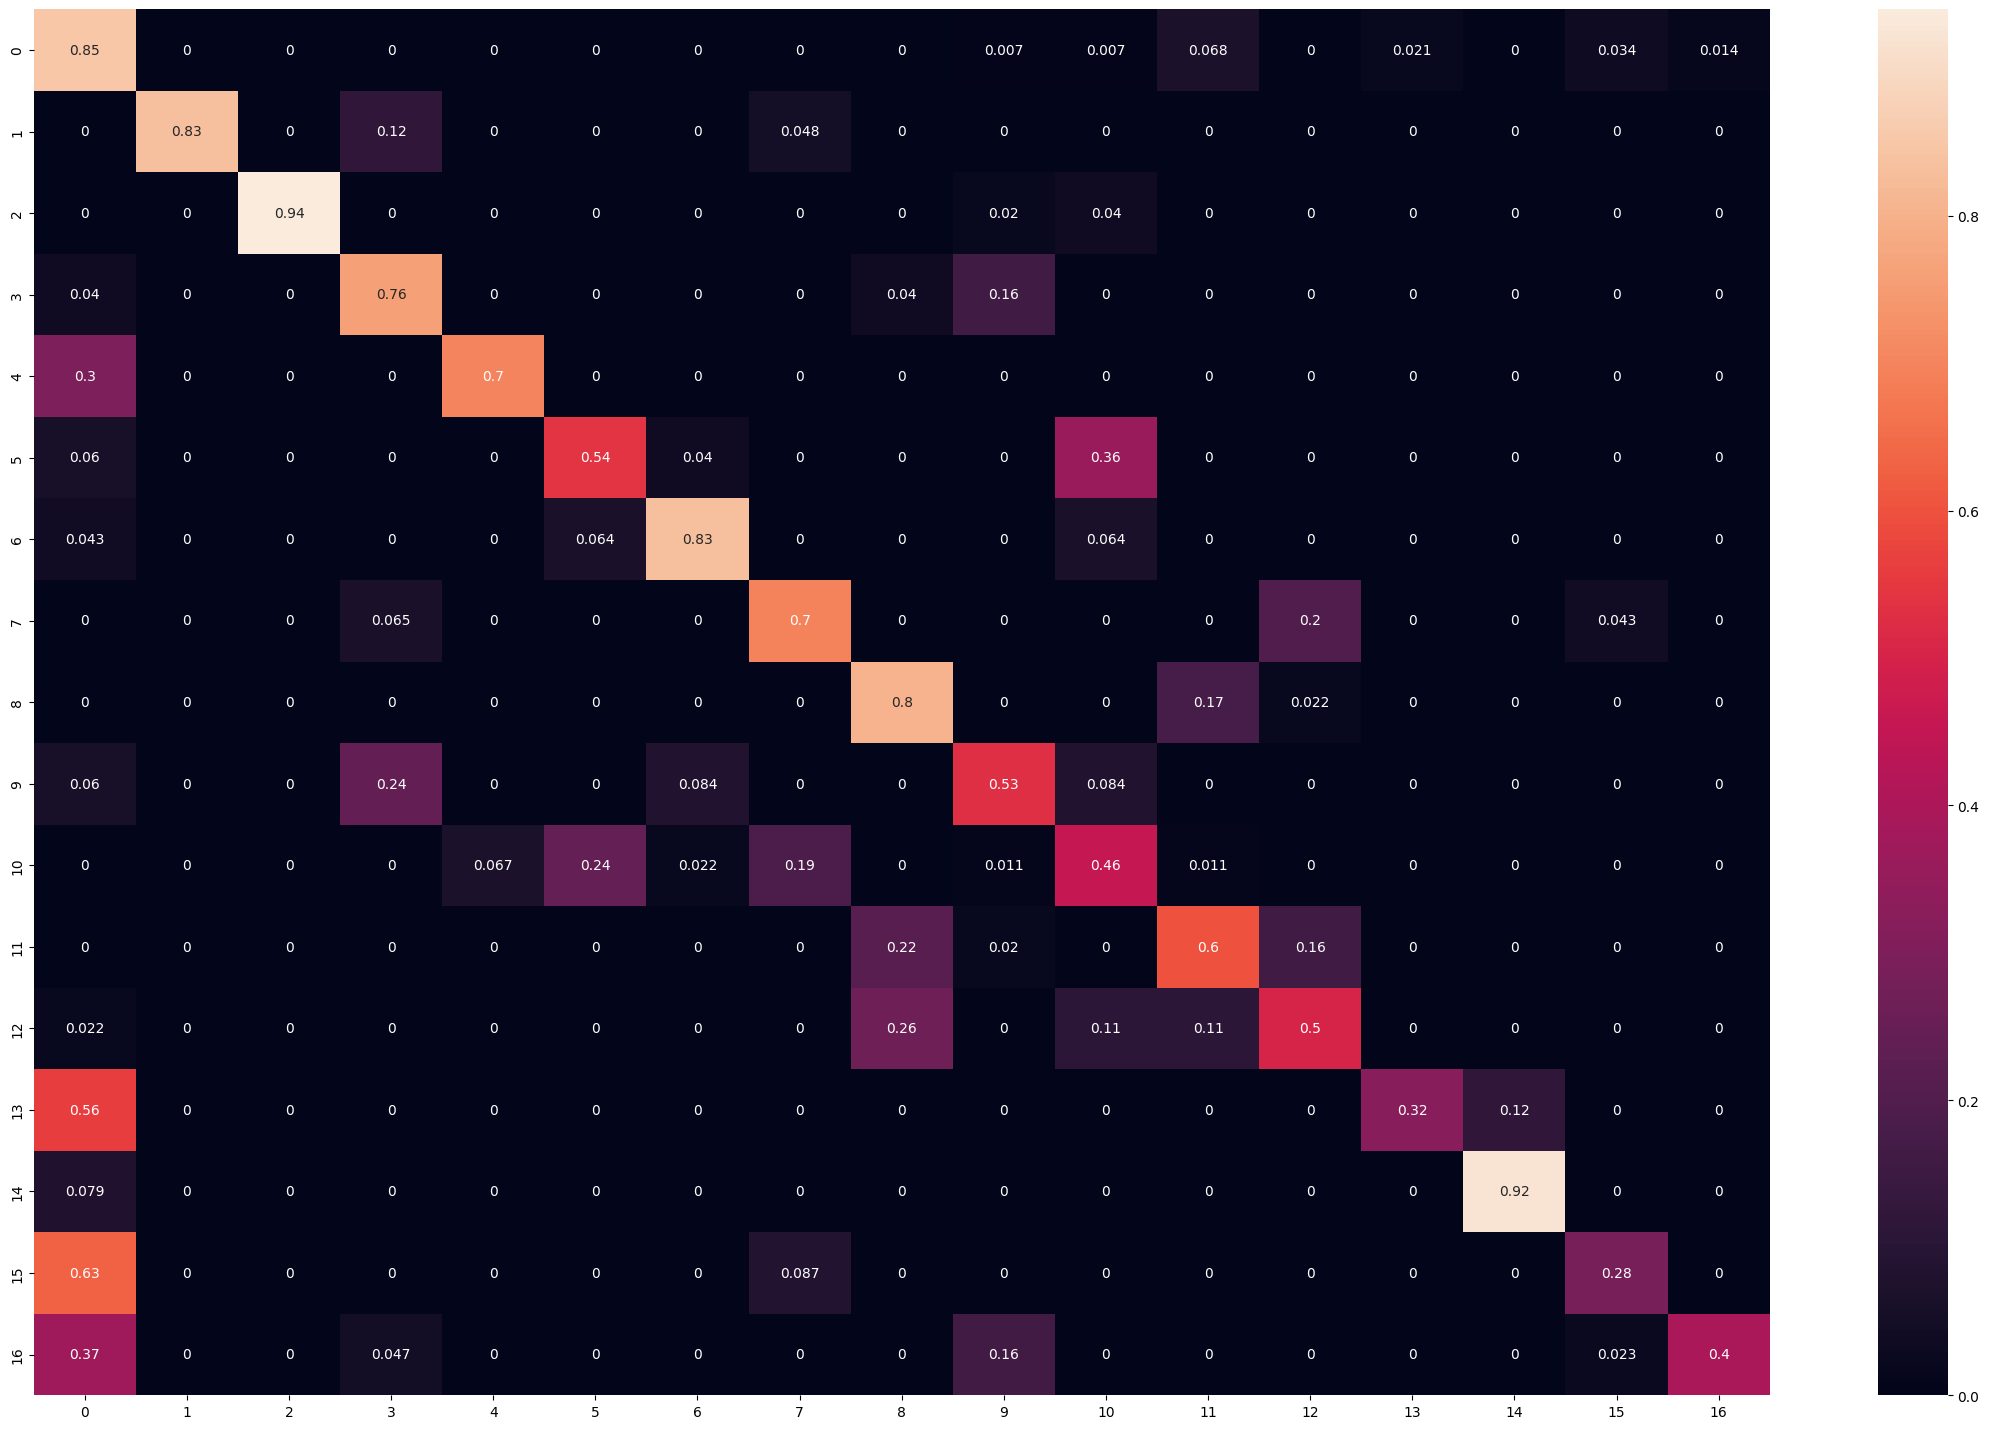

In [14]:
curr_test_ids_test = filt_unique_ids
subset = merged1[
    merged1["id"].isin(curr_test_ids_test)
].reset_index(drop=True)

true_labels, pred_labels = algo_test(
    subset,
    model=MODEL_META["svc"],
    cols_meta=meta_cols_all_combs,
    random_state=42,
    max_folds=MAX_SELECTION_FOLDS
)

### Logistic regression

In [15]:
meta_scores_all_combs_lr = {}
meta_cols_all_combs_lr = {}

for comb in tqdm(all_combs):
    score, cols = feature_selection(
        single_id_subset,
        comb,
        model=MODEL_META["lr"],
        n_feats=60,
        random_state=42,
        max_folds=MAX_SELECTION_FOLDS
    )
    meta_scores_all_combs_lr[comb] = float(score)
    meta_cols_all_combs_lr[comb] = list(cols)

    del score, cols
    gc.collect()

100%|██████████| 136/136 [00:30<00:00,  4.39it/s]


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')
Balanced preliminary folds: 10


Preliminary evaluation folds: 100%|██████████| 10/10 [00:06<00:00,  1.46it/s]


{0: '0000000_', 1: '0000001_', 2: '0000002_', 3: '0000010_', 4: '0000020_', 5: '0000100_', 6: '0000200_', 7: '0000300_', 8: '0000400_', 9: '0001000_', 10: '0002000_', 11: '0010000_', 12: '0020000_', 13: '0100000_', 14: '0300000_', 15: '1000000_', 16: '2000000_'}
              precision    recall  f1-score   support

    0000000_       0.76      0.71      0.74       146
    0000001_       1.00      1.00      1.00        42
    0000002_       0.96      1.00      0.98        50
    0000010_       0.62      0.98      0.76        50
    0000020_       0.83      0.76      0.79        50
    0000100_       0.53      0.82      0.65        50
    0000200_       0.65      0.89      0.75        47
    0000300_       0.62      0.83      0.71        46
    0000400_       0.63      0.83      0.72        46
    0001000_       0.89      0.65      0.75        83
    0002000_       0.71      0.27      0.39        90
    0010000_       0.67      0.74      0.70        50
    0020000_       0.91      0.67 

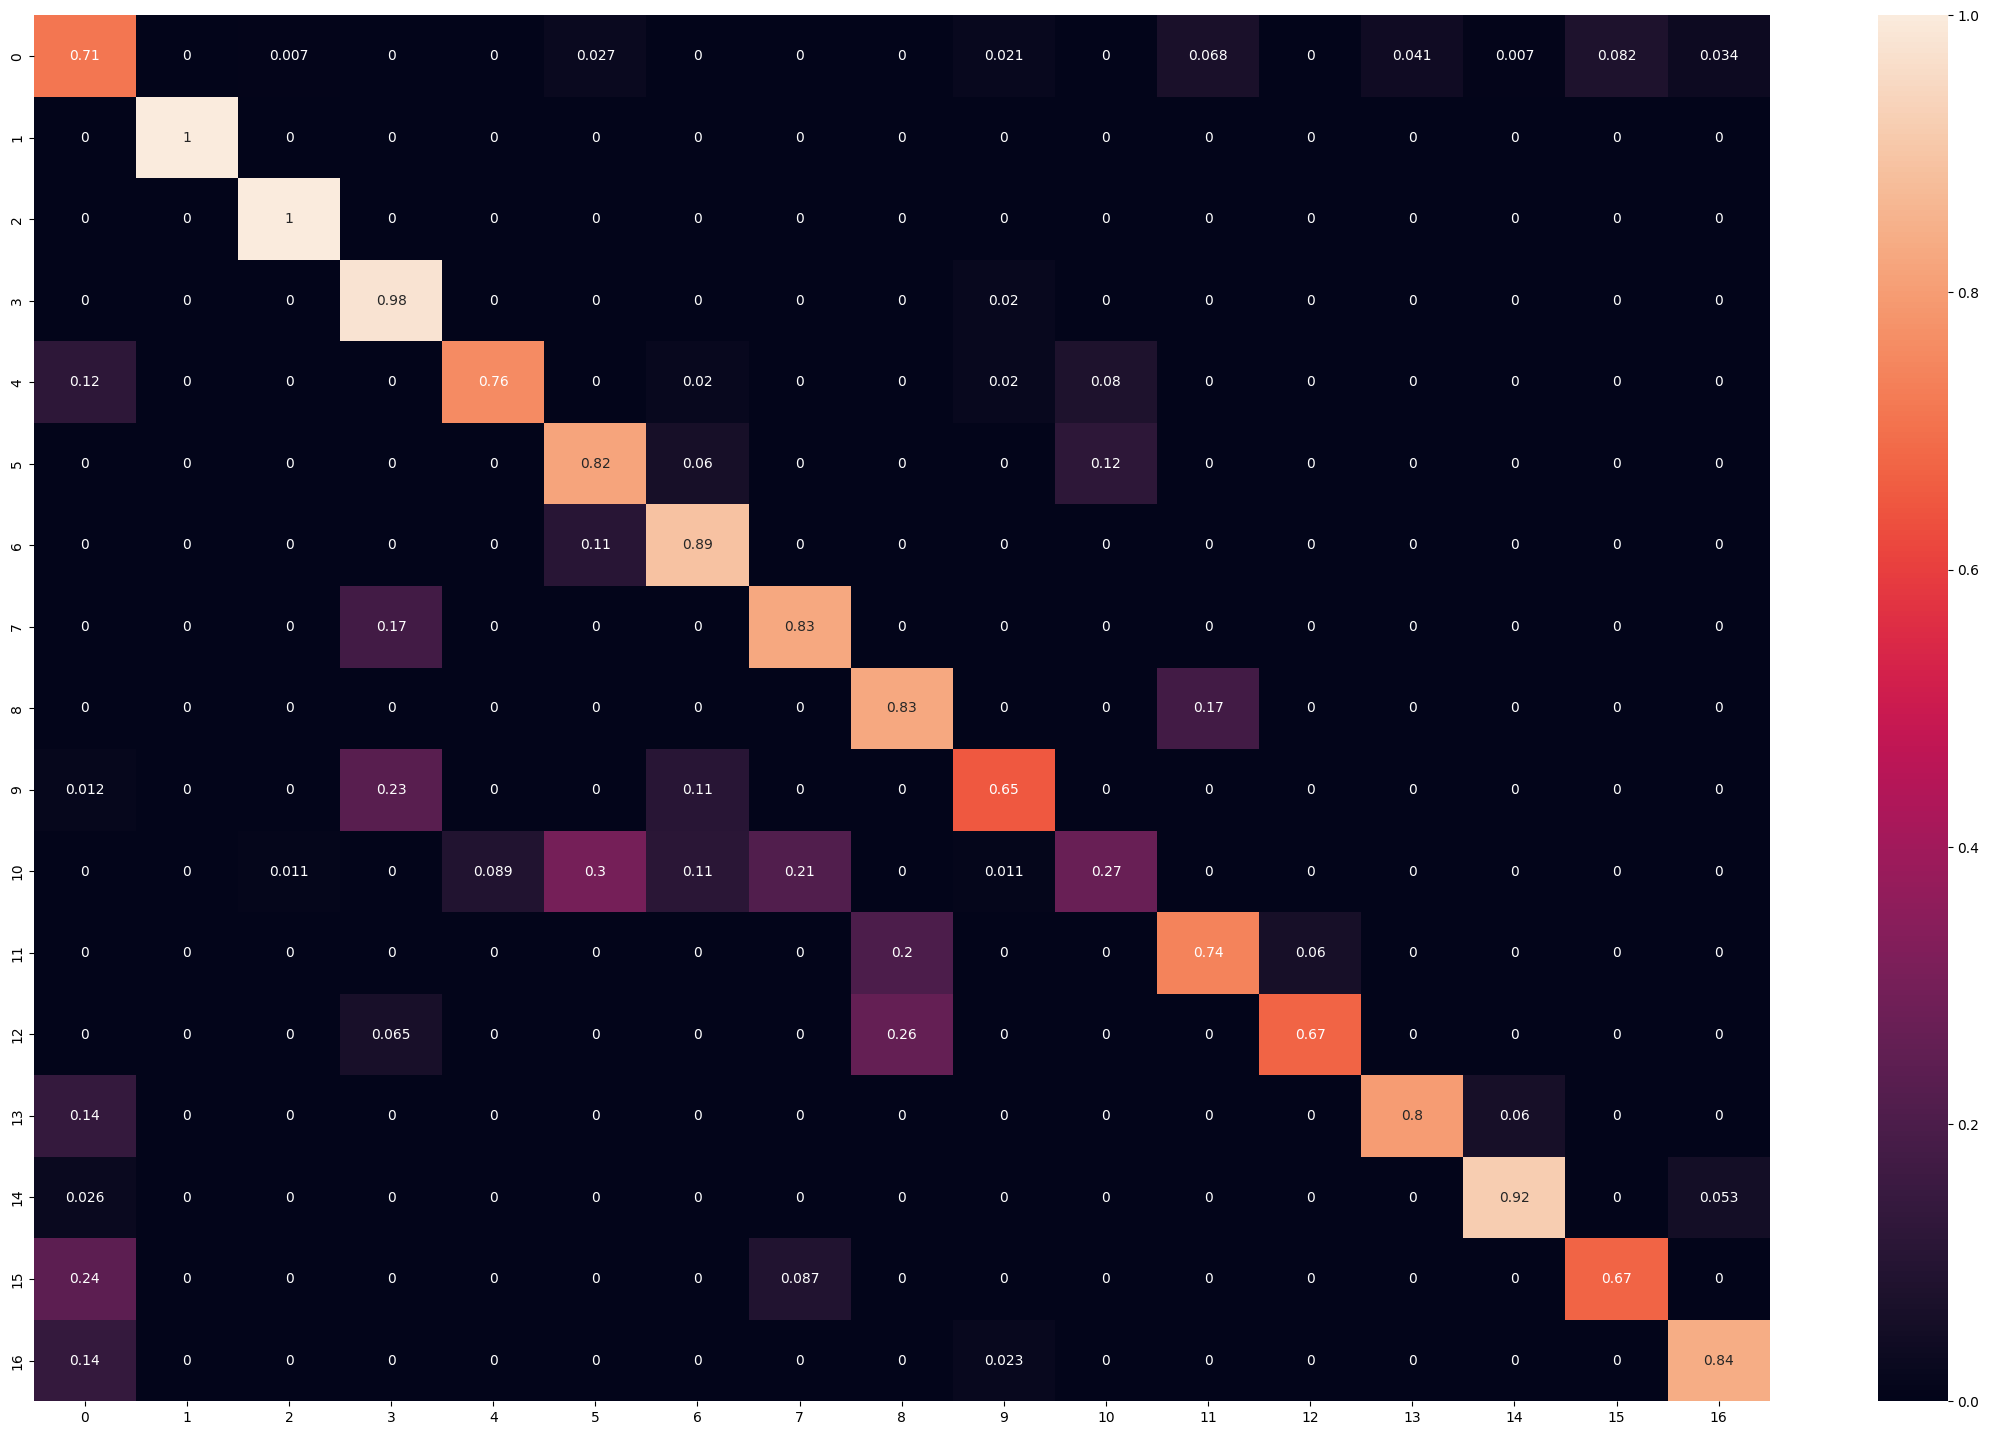

In [16]:
curr_test_ids_test = filt_unique_ids
subset = merged1[
    merged1["id"].isin(curr_test_ids_test)
].reset_index(drop=True)

true_labels, pred_labels = algo_test(
    subset,
    model=MODEL_META["lr"],
    cols_meta=meta_cols_all_combs_lr,
    random_state=42,
    max_folds=MAX_SELECTION_FOLDS
)

### Decision tree

In [17]:
meta_scores_all_combs_dt = {}
meta_cols_all_combs_dt = {}

for comb in tqdm(all_combs):
    score, cols = feature_selection(
        single_id_subset,
        comb,
        model=MODEL_META["dt"],
        n_feats=60,
        random_state=42,
        max_folds=MAX_SELECTION_FOLDS
    )
    meta_scores_all_combs_dt[comb] = float(score)
    meta_cols_all_combs_dt[comb] = list(cols)

    del score, cols
    gc.collect()

100%|██████████| 136/136 [00:31<00:00,  4.30it/s]


DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=2,
                       random_state=42)
Balanced preliminary folds: 10


Preliminary evaluation folds: 100%|██████████| 10/10 [00:07<00:00,  1.42it/s]


{0: '0000000_', 1: '0000001_', 2: '0000002_', 3: '0000010_', 4: '0000020_', 5: '0000100_', 6: '0000200_', 7: '0000300_', 8: '0000400_', 9: '0001000_', 10: '0002000_', 11: '0010000_', 12: '0020000_', 13: '0100000_', 14: '0300000_', 15: '1000000_', 16: '2000000_'}
              precision    recall  f1-score   support

    0000000_       0.47      0.82      0.60       146
    0000001_       0.98      1.00      0.99        42
    0000002_       0.85      0.44      0.58        50
    0000010_       0.33      0.30      0.31        50
    0000020_       0.71      0.60      0.65        50
    0000100_       0.74      0.58      0.65        50
    0000200_       0.54      0.40      0.46        47
    0000300_       0.32      0.39      0.35        46
    0000400_       0.40      0.61      0.48        46
    0001000_       0.38      0.54      0.45        83
    0002000_       0.23      0.21      0.22        90
    0010000_       0.52      0.34      0.41        50
    0020000_       0.61      0.41 

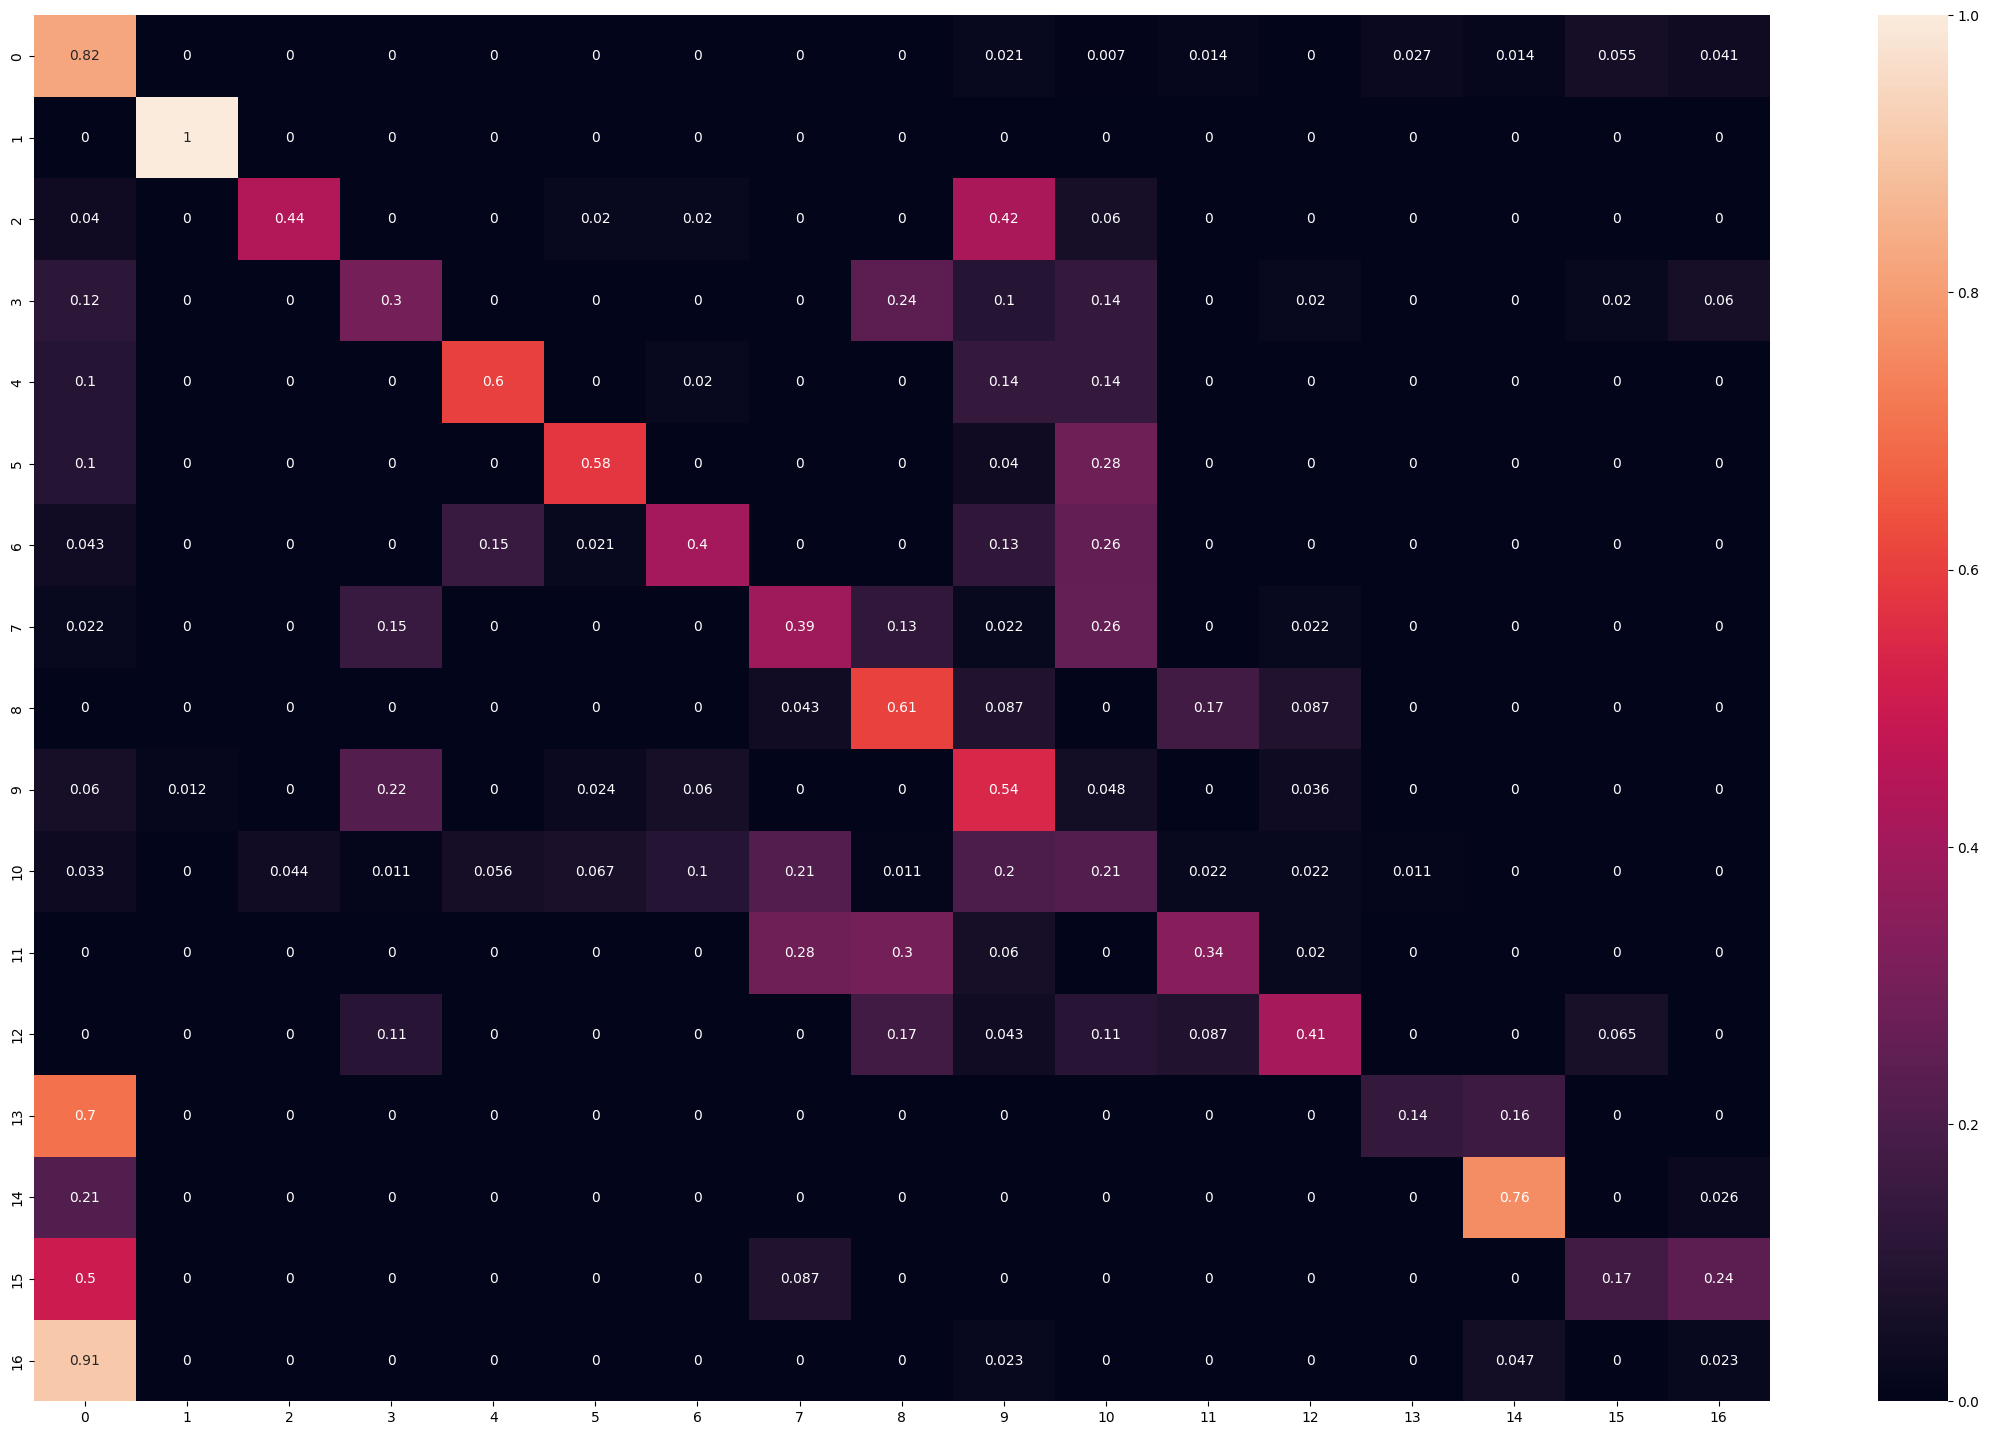

In [18]:
curr_test_ids_test = filt_unique_ids
subset = merged1[
    merged1["id"].isin(curr_test_ids_test)
].reset_index(drop=True)

true_labels, pred_labels = algo_test(
    subset,
    model=MODEL_META["dt"],
    cols_meta=meta_cols_all_combs_dt,
    random_state=42,
    max_folds=MAX_SELECTION_FOLDS
)

## 10. Combined model selection and ensemble

Choose the strongest model for each fault pair, assemble its selected features, and define the ensemble transformer.

In [19]:
expected_pairs = set(all_combs)

for name, scores, cols in [
    ("SVC", meta_scores_all_combs, meta_cols_all_combs),
    ("LR", meta_scores_all_combs_lr, meta_cols_all_combs_lr),
    ("DT", meta_scores_all_combs_dt, meta_cols_all_combs_dt)
]:
    missing_scores = expected_pairs - set(scores)
    missing_cols = expected_pairs - set(cols)
    if missing_scores or missing_cols:
        raise ValueError(
            f"{name} incomplete. "
            f"Missing scores={len(missing_scores)}, "
            f"missing columns={len(missing_cols)}"
        )

models_efficiency_list = {}
meta_combined_model_cols = {}
meta_combined_model_scores = {}

for key in all_combs:
    scores = {
        "lr": float(meta_scores_all_combs_lr[key]),
        "svc": float(meta_scores_all_combs[key]),
        "dt": float(meta_scores_all_combs_dt[key])
    }
    best_model = max(scores, key=scores.get)

    models_efficiency_list[key] = best_model
    if best_model == "lr":
        meta_combined_model_cols[key] = meta_cols_all_combs_lr[key]
    elif best_model == "svc":
        meta_combined_model_cols[key] = meta_cols_all_combs[key]
    else:
        meta_combined_model_cols[key] = meta_cols_all_combs_dt[key]

    meta_combined_model_scores[key] = scores[best_model]

print("Selected models:")
print(pd.Series(models_efficiency_list).value_counts())
print("Total pairs:", len(models_efficiency_list))

Selected models:
lr     83
svc    34
dt     19
Name: count, dtype: int64
Total pairs: 136


In [20]:
class CombModelTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, model=None, ids='', columns=None):
        self.model = model
        self.ids = ids
        self.columns = columns

    def fit(self, X, y=None):
        list_ids = self.ids.split('@')
        X = pd.DataFrame(X, columns=self.columns)
        X = X[X['id'].isin(list_ids)].reset_index(drop=True)
        y = X['id']
        X = X.drop(drop_cols, axis=1)
        self.scaler_ = RobustScaler()
        X = self.scaler_.fit_transform(X)
        self.model_ = copy.deepcopy(self.model)
        self.model_.fit(X, y)
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns)
        X = X.drop(drop_cols, axis=1)
        X = self.scaler_.transform(X)
        return self.model_.predict(X).reshape(-1, 1)


In [21]:
def comb_algo_test(df, cols_meta=None, random_state=42):
    model_meta = MODEL_META
    true_labels = []
    pred_labels = []

    le = LabelEncoder()
    _ = le.fit_transform(df["id"])
    mapped_classes = {
        i: class_id for i, class_id in enumerate(le.classes_)
    }

    combined_process = FeatureUnion([
        (
            f"pipe_{i}",
            Pipeline([
                (
                    f"{key}ct",
                    ColumnTransformer(
                        transformers=[
                            ("cols", "passthrough", cols + drop_cols)
                        ]
                    )
                ),
                (
                    f"{key}model",
                    CombModelTransformer(
                        model=model_meta[models_efficiency_list[key]],
                        ids=key,
                        columns=cols + drop_cols
                    )
                )
            ])
        )
        for i, (key, cols) in enumerate(cols_meta.items())
    ])

    split_plan, n_folds = build_fan_combination_plan(
        df,
        random_state=random_state,
        max_folds=None
    )
    print("Exhaustive fan-combination folds:", n_folds)

    for fold in tqdm(range(n_folds), desc="Final exhaustive folds"):
        train_data, test_data = train_test_split_2(
            df,
            fold=fold,
            split_plan=split_plan,
            n_folds=n_folds
        )

        iter_combined_process = copy.deepcopy(combined_process)
        iter_combined_process.fit(train_data)
        output = iter_combined_process.transform(test_data)

        pred_labels.extend([mode(arr) for arr in output])
        true_labels.extend(test_data["id"].tolist())

        del iter_combined_process, output
        del train_data, test_data

        if (fold + 1) % 10 == 0:
            gc.collect()

    gc.collect()

    plt.figure(figsize=(28, 18))
    conf_matr = confusion_matrix(true_labels, pred_labels)
    arr_true_labels = np.array(true_labels)
    sample_weights = [
        arr_true_labels[arr_true_labels == class_id].shape[0]
        for class_id in sorted(np.unique(arr_true_labels))
    ]
    normalized_conf_matr = np.round(
        np.array([
            row / sample_weights[i]
            for i, row in enumerate(conf_matr)
        ]),
        3
    )
    sns.heatmap(normalized_conf_matr, annot=True)

    print(mapped_classes)
    print(classification_report(true_labels, pred_labels, zero_division=0))
    print(
        "Macro F1:",
        f1_score(true_labels, pred_labels, average="macro", zero_division=0)
    )
    print(
        "Weighted F1:",
        f1_score(true_labels, pred_labels, average="weighted", zero_division=0)
    )

    return true_labels, pred_labels

## 11. Combined evaluation and defect-level reporting

Evaluate the selected-model ensemble over every per-fault test-fan combination and report normalized confusion matrices and F1 scores at both fault-ID and defect-label levels. This is intentionally the longest evaluation stage.

### Ensemble evaluation

Exhaustive fan-combination folds: 5460


Final exhaustive folds: 100%|██████████| 5460/5460 [1:05:05<00:00,  1.40it/s]


{0: '0000000_', 1: '0000001_', 2: '0000002_', 3: '0000010_', 4: '0000020_', 5: '0000100_', 6: '0000200_', 7: '0000300_', 8: '0000400_', 9: '0001000_', 10: '0002000_', 11: '0010000_', 12: '0020000_', 13: '0100000_', 14: '0300000_', 15: '1000000_', 16: '2000000_'}
              precision    recall  f1-score   support

    0000000_       0.74      0.78      0.76     77805
    0000001_       1.00      1.00      1.00     23660
    0000002_       0.96      0.76      0.85     27300
    0000010_       0.66      0.81      0.73     27300
    0000020_       0.83      0.65      0.73     27300
    0000100_       0.51      0.76      0.61     27300
    0000200_       0.64      0.88      0.74     25480
    0000300_       0.61      0.92      0.73     25480
    0000400_       0.57      0.84      0.68     25480
    0001000_       0.85      0.68      0.75     45045
    0002000_       0.34      0.21      0.26     49140
    0010000_       0.71      0.62      0.66     27300
    0020000_       0.75      0.53 

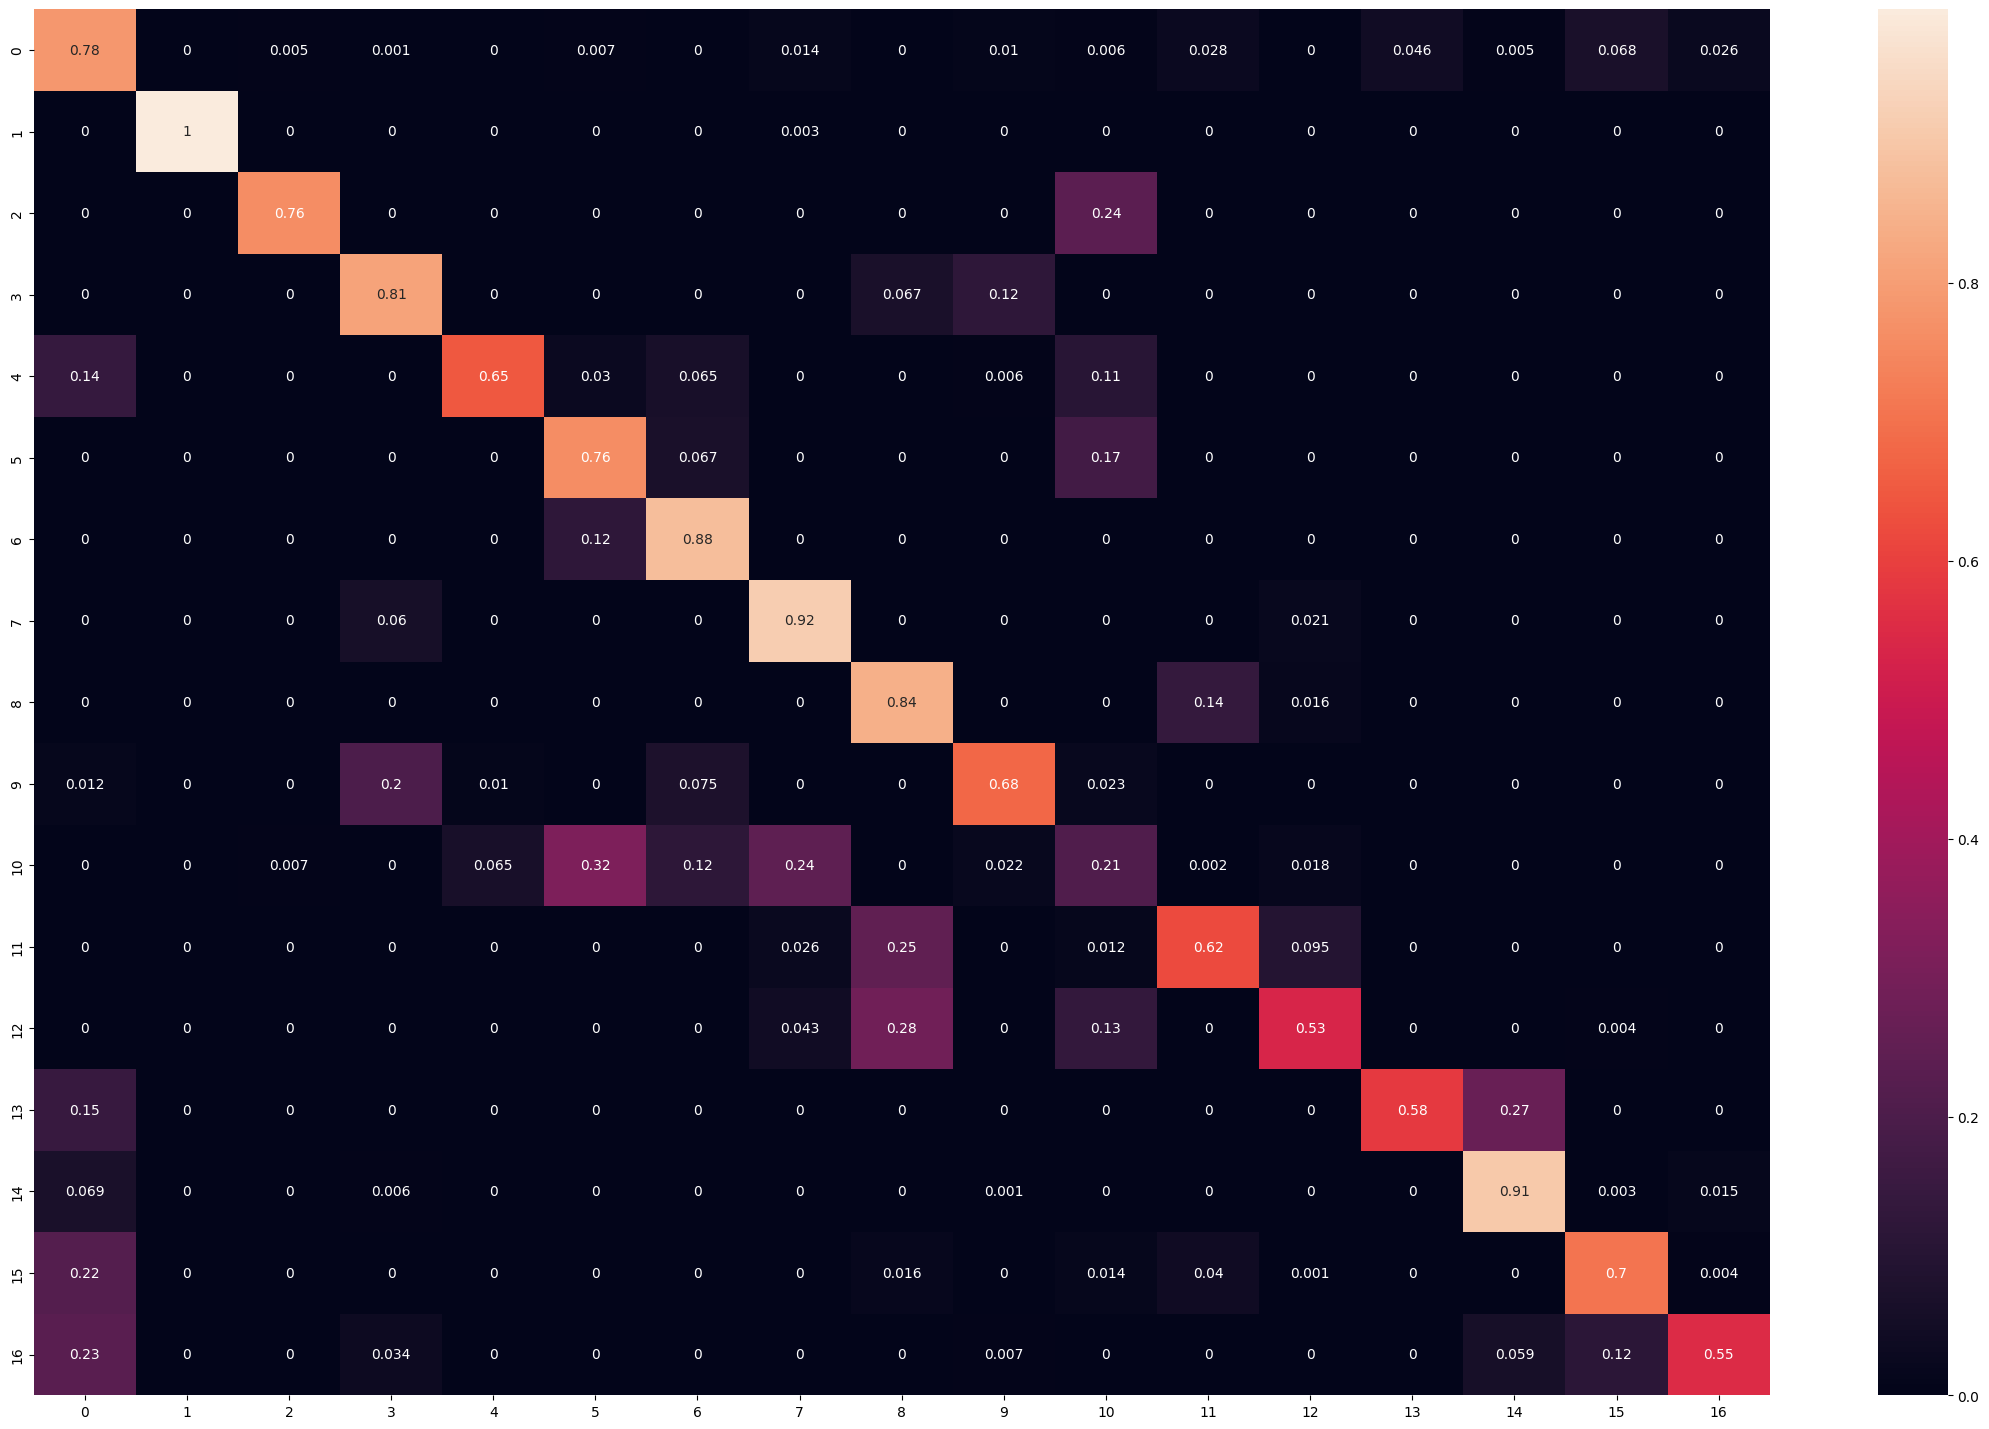

In [22]:
true_labels, pred_labels = comb_algo_test(
    subset,
    cols_meta=meta_combined_model_cols,
    random_state=42
)

### Defect-label evaluation

              precision    recall  f1-score   support

           0       0.74      0.78      0.76     77805
           A       0.81      0.69      0.75     49140
           B       0.89      0.88      0.88     47320
           C       0.79      0.63      0.70     52780
           D       0.65      0.46      0.54     94185
           E       0.61      0.90      0.73    103740
           F       0.72      0.73      0.73     54600
           G       0.98      0.87      0.92     50960

    accuracy                           0.73    530530
   macro avg       0.78      0.74      0.75    530530
weighted avg       0.75      0.73      0.73    530530

0.7300625557037279
Macro F1: 0.7504486879172507
Weighted F1: 0.7300625557037279
A_1: Motor cover imbalance, B_2: Tight Bearing, C_3: Rotor imbalance, D_4: Stator-rotor rubbing, E_5: Winding data mistake, 
F_6: Rotor skew angle variation,  G_7: Die casting defect


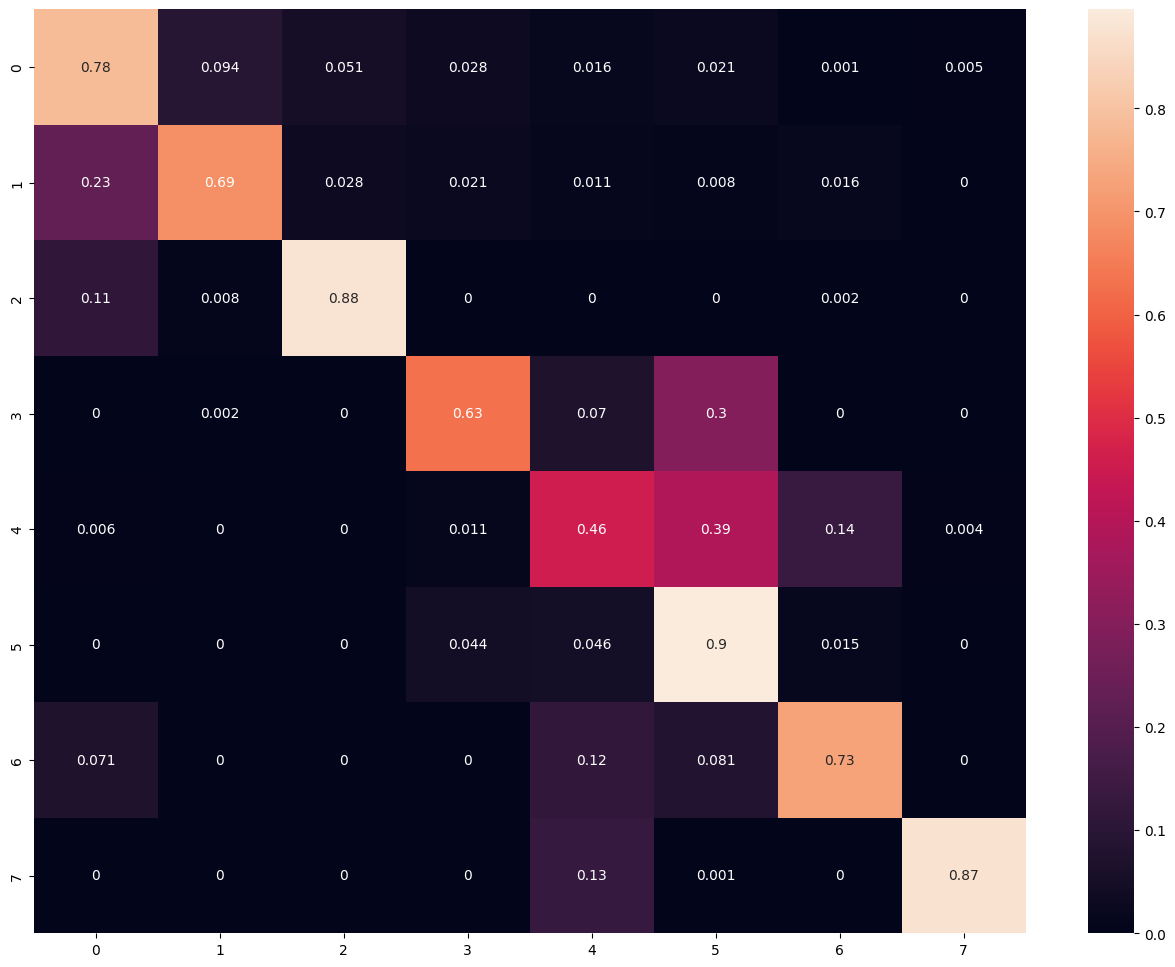

In [23]:
true_defects = [complete_class_label_meta[label] for label in true_labels]
pred_defects = [complete_class_label_meta[label] for label in pred_labels]
plt.figure(figsize=(16, 12))
conf_matr = confusion_matrix(true_defects, pred_defects)
arr_true_defects = np.array(true_defects)
sample_weights = [arr_true_defects[arr_true_defects == clsid].shape[0] for clsid in sorted(np.unique(arr_true_defects))]
updt_conf_matr = np.matrix.round(np.array([row / sample_weights[i] for i, row in enumerate(conf_matr)]), 3)
sns.heatmap(updt_conf_matr, annot=True)
print(classification_report(true_defects, pred_defects))
print(f1_score(true_defects, pred_defects, average='weighted'))
print('Macro F1:', f1_score(true_defects, pred_defects, average='macro', zero_division=0))
print('Weighted F1:', f1_score(true_defects, pred_defects, average='weighted', zero_division=0))
print('A_1: Motor cover imbalance, B_2: Tight Bearing, C_3: Rotor imbalance, D_4: Stator-rotor rubbing, E_5: Winding data mistake, \nF_6: Rotor skew angle variation,  G_7: Die casting defect')


In [24]:
print('1: Motor cover imbalance, 2: Tight Bearing, 3: Rotor imbalance, 4: Stator-rotor rubbing, 5: Winding data mistake, \n6: Rotor skew angle variation,  7: Die casting defect')


1: Motor cover imbalance, 2: Tight Bearing, 3: Rotor imbalance, 4: Stator-rotor rubbing, 5: Winding data mistake, 
6: Rotor skew angle variation,  7: Die casting defect


              precision    recall  f1-score   support

     Healthy       0.74      0.78      0.76     77805
 Non-Healthy       0.96      0.95      0.96    452725

    accuracy                           0.93    530530
   macro avg       0.85      0.87      0.86    530530
weighted avg       0.93      0.93      0.93    530530

0.9296117044743167
Macro F1: 0.8608848220121357
Weighted F1: 0.9296117044743167
Healthy: 0000000_, Non-Healthy: all remaining fan IDs


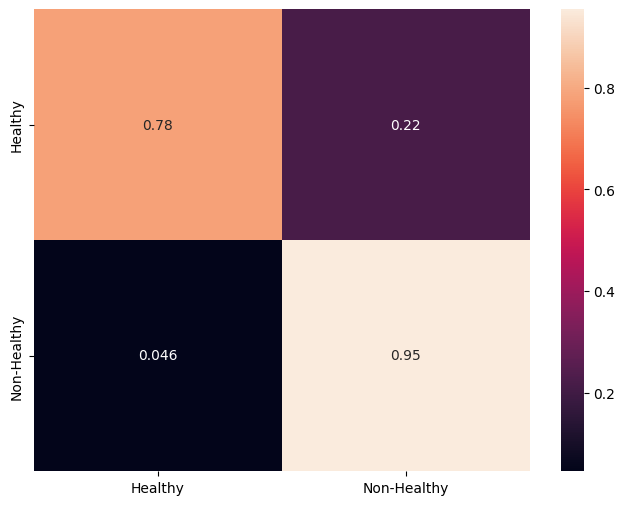

In [ ]:
healthy_label = '0000000_' + top

true_health = ['Healthy' if label == healthy_label else 'Non-Healthy' for label in true_labels]

pred_health = ['Healthy' if label == healthy_label else 'Non-Healthy' for label in pred_labels]

plt.figure(figsize=(8, 6))

conf_matr = confusion_matrix(true_health, pred_health)

arr_true_health = np.array(true_health)

sample_weights = [arr_true_health[arr_true_health == clsid].shape[0]
                  for clsid in sorted(np.unique(arr_true_health))]

updt_conf_matr = np.matrix.round(
    np.array([row / sample_weights[i] for i, row in enumerate(conf_matr)]),
    3
)

sns.heatmap(
    updt_conf_matr,
    annot=True,
    xticklabels=sorted(np.unique(arr_true_health)),
    yticklabels=sorted(np.unique(arr_true_health))
)

print(classification_report(true_health, pred_health))

print(f1_score(true_health, pred_health, average='weighted'))

print('Macro F1:',
      f1_score(true_health, pred_health, average='macro', zero_division=0))

print('Weighted F1:',
      f1_score(true_health, pred_health, average='weighted', zero_division=0))

print('Healthy: 0000000_, Non-Healthy: all remaining fan IDs')

In [28]:
# Select which final exhaustive fold you want to inspect.
# Valid values: 0 to audit_n_folds - 1
AUDIT_FOLD = 1000

audit_plan, audit_n_folds = build_fan_combination_plan(
    subset,
    random_state=42,
    max_folds=None  # Complete exhaustive final-evaluation plan
)

if not 0 <= AUDIT_FOLD < audit_n_folds:
    raise ValueError(
        f"AUDIT_FOLD must be between 0 and {audit_n_folds - 1}"
    )

audit_train, audit_test = train_test_split_2(
    subset,
    fold=AUDIT_FOLD,
    split_plan=audit_plan,
    n_folds=audit_n_folds
)

audit_rows = []

for fault_id in sorted(subset["id"].unique()):
    testing_fans = sorted(
        audit_test.loc[
            audit_test["id"] == fault_id,
            "fan_no"
        ].astype(int).unique().tolist()
    )

    training_fans = sorted(
        audit_train.loc[
            audit_train["id"] == fault_id,
            "fan_no"
        ].astype(int).unique().tolist()
    )

    audit_rows.append({
        "fault_id": fault_id,
        "testing_fans": testing_fans,
        "training_fans": training_fans,
        "total_test_combinations": len(audit_plan[fault_id])
    })

fan_split_audit = pd.DataFrame(audit_rows)

print(
    f"Final evaluation has {audit_n_folds} folds. "
    f"Showing fold {AUDIT_FOLD}."
)
print(
    "Because validation is exhaustive, there is no permanent split: "
    "every fan enters testing in some folds and training in other folds."
)

fan_split_audit

Final evaluation has 5460 folds. Showing fold 1000.
Because validation is exhaustive, there is no permanent split: every fan enters testing in some folds and training in other folds.


,fault_id,testing_fans,training_fans,total_test_combinations
0,0000000_,"[0, 2, 8, 10]","[1, 3, 4, 5, 6, 7, 9, 11, 14, 15, 16, 18]",1820
1,0000001_,[1],"[0, 2]",3
2,0000002_,[0],"[1, 2]",3
3,0000010_,[2],"[0, 1]",3
4,0000020_,[1],"[0, 2]",3
5,0000100_,[0],"[1, 2]",3
6,0000200_,[2],"[0, 1]",3
7,0000300_,[1],"[0, 2]",3
8,0000400_,[0],"[1, 2]",3
9,0001000_,"[3, 4]","[0, 1, 2, 5, 8, 11]",28


## 12. Export artifacts and audit merged coverage

Save selected features/model choices and verify expected samples are represented in the merged dataset.

### Export model metadata and merged datasets

In [29]:
with open('combwise_cols_lr_svc_clean_exhaustive_fans.json', 'w') as f:
    json.dump(meta_combined_model_cols, f)
with open('combwise_scores_lr_svc_clean_exhaustive_fans.json', 'w') as f:
    json.dump(meta_combined_model_scores, f)
with open('combwise_model_selection_lr_svc_clean_exhaustive_fans.json', 'w') as f:
    json.dump(models_efficiency_list, f)
merged.to_csv('merged_clean_exhaustive_fans.csv', index=False)
print('Final merged samples:', merged['sample_id_key'].nunique())
print('\nSamples per fault:')
print(merged.groupby('id').size())
if merged['sample_id_key'].duplicated().any():
    raise ValueError('Duplicate sample_id_key found in merged data')
merged1.to_csv('merged_clean_model_input_exhaustive_fans.csv', index=False)


Final merged samples: 344

Samples per fault:
id
0000000_    57
0000001_    13
0000002_    15
0000010_    15
0000020_    15
0000100_    15
0000200_    14
0000300_    14
0000400_    14
0001000_    33
0002000_    27
0010000_    15
0020000_    14
0030000_    15
0100000_    15
0200000_    15
0300000_    11
1000000_    14
2000000_    13
dtype: int64


### Coverage audit

In [26]:
# meta_check = pd.read_csv('meta_combined_all_faults_mapped.csv', dtype={'fault_id': str})
# meta_check['sample_id_key'] = meta_check['fault_id'] + '@' + meta_check['fan_id'].astype(int).astype(str) + '@' + meta_check['sample_id'].astype(int).astype(str)
# check = meta_check[meta_check['fault_id'].isin(['0000000_', '0001000_']) & (meta_check['fan_id'] >= 10)].copy()
# merged_keys = set(merged['sample_id_key'])
# check['included_in_merged'] = check['sample_id_key'].isin(merged_keys)
# report = check.groupby(['fault_id', 'fan_id']).agg(expected=('sample_id_key', 'size'), included=('included_in_merged', 'sum'))
# report['missing'] = report['expected'] - report['included']
# print(report)
# print('\nMissing sample keys:')
# print(check.loc[~check['included_in_merged'], 'sample_id_key'].to_string(index=False))
